# AI Imaging Assignment — Hybrid Segmentation and LLM Pipeline

## Task 2 and Task 4: Classical Features, U-Net Segmentation and LLM Interpretation

This notebook implements the hybrid analysis pipeline on the unseen test images.

### Pipeline

**Test image → preprocessing → U-Net segmentation → connected components → region properties → numerical summary → local LLM → structured JSON + narrative**

The LLM receives the numerical feature summary only. It does not receive the image during the numbers-first interpretation stage.

### Main outputs

1. Classical image segmentation and connected-component features
2. Per-image numerical feature summaries
3. LLM-generated structured JSON records
4. LLM-generated descriptive narratives
5. Comparison-ready outputs for Task 2
6. Aggregated test-set results saved as CSV for Task 4

The LLM is used as a descriptive interpretation component rather than a diagnostic system.

In [2]:
# ============================================================
# CELL 2 — IMPORTS AND CONFIGURATION
# ============================================================

import os
import json
import re
import requests
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from scipy import ndimage
from skimage import filters, morphology, measure
from skimage.measure import regionprops_table

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset, Model and Test-Image Preparation

The required project paths, unseen test images and trained U-Net checkpoint are verified before inference. The test set is kept separate from the training data, and the trained checkpoint is loaded without further training.

The test images are then converted into the numerical format expected by the U-Net.

In [3]:
# ============================================================
# CELL 3 — PROJECT PATHS
# ============================================================

PROJECT_ROOT = r"C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3"

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
NUCLEI_DATASET_DIR = os.path.join(RAW_DATA_DIR, "nuclei_dataset")

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

# ------------------------------------------------------------
# Test dataset
# ------------------------------------------------------------

TEST_DIR = os.path.join(
    NUCLEI_DATASET_DIR,
    "test"
)

TEST_IMAGE_DIR = os.path.join(
    TEST_DIR,
    "images"
)

TEST_MASK_DIR = os.path.join(
    TEST_DIR,
    "masks"
)

# ------------------------------------------------------------
# Trained U-Net checkpoint
# ------------------------------------------------------------

CHECKPOINT_PATH = os.path.join(
    MODEL_DIR,
    "best_unet_nuclei.pth"
)

# ------------------------------------------------------------
# Hybrid pipeline outputs
# ------------------------------------------------------------

HYBRID_OUTPUT_DIR = os.path.join(
    OUTPUT_DIR,
    "hybrid_pipeline"
)

os.makedirs(HYBRID_OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("PROJECT PATHS")
print("=" * 70)

print("Project root :", PROJECT_ROOT)
print("Dataset root :", NUCLEI_DATASET_DIR)
print("Test images  :", TEST_IMAGE_DIR)
print("Test masks   :", TEST_MASK_DIR)
print("Checkpoint   :", CHECKPOINT_PATH)
print("Output dir   :", HYBRID_OUTPUT_DIR)

PROJECT PATHS
Project root : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3
Dataset root : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset
Test images  : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\test\images
Test masks   : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\data\raw\nuclei_dataset\test\masks
Checkpoint   : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\models\best_unet_nuclei.pth
Output dir   : C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline


In [4]:
# ============================================================
# CELL 4 — VERIFY DATASET AND CHECKPOINT
# ============================================================

print("=" * 70)
print("DATASET AND CHECKPOINT VERIFICATION")
print("=" * 70)

# Check directories
print("\nTest image directory exists :", os.path.exists(TEST_IMAGE_DIR))
print("Test mask directory exists  :", os.path.exists(TEST_MASK_DIR))
print("Checkpoint exists            :", os.path.exists(CHECKPOINT_PATH))

# List test images
if os.path.exists(TEST_IMAGE_DIR):
    test_image_files = sorted([
        f for f in os.listdir(TEST_IMAGE_DIR)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
    ])
else:
    test_image_files = []

print("\nNumber of test images:", len(test_image_files))

print("\nTest images:")
for f in test_image_files:
    print(" ", f)

# Check checkpoint size
if os.path.exists(CHECKPOINT_PATH):
    checkpoint_size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024 ** 2)
    print(f"\nCheckpoint size: {checkpoint_size_mb:.2f} MB")

print("\nVerification complete.")

DATASET AND CHECKPOINT VERIFICATION

Test image directory exists : True
Test mask directory exists  : True
Checkpoint exists            : True

Number of test images: 12

Test images:
  test_000.png
  test_001.png
  test_002.png
  test_003.png
  test_004.png
  test_005.png
  test_006.png
  test_007.png
  test_008.png
  test_009.png
  test_010.png
  test_011.png

Checkpoint size: 118.48 MB

Verification complete.


## 2. U-Net Segmentation of Unseen Images

The trained U-Net is applied to each unseen test image to produce a pixel-level probability map and binary segmentation mask. Prediction diagnostics and a small visual sample are used to check the behaviour of the masks before they are passed to the next stage of the pipeline.

In [7]:
# ============================================================
# CELL 6 — LOAD AND VERIFY U-NET CHECKPOINT
# ============================================================

print("=" * 70)
print("LOADING TRAINED U-NET CHECKPOINT")
print("=" * 70)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)

# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

print("Checkpoint type:", type(checkpoint))

# ------------------------------------------------------------
# Handle different checkpoint formats
# ------------------------------------------------------------

if isinstance(checkpoint, dict):

    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    elif "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    else:
        # The checkpoint may itself be the state_dict
        state_dict = checkpoint

else:
    raise TypeError(
        "Unsupported checkpoint format: "
        f"{type(checkpoint)}"
    )

# Remove possible DataParallel prefix
clean_state_dict = {}

for key, value in state_dict.items():

    clean_key = key.replace("module.", "")

    clean_state_dict[clean_key] = value


# ------------------------------------------------------------
# Check compatibility BEFORE loading
# ------------------------------------------------------------

model_keys = set(model.state_dict().keys())
checkpoint_keys = set(clean_state_dict.keys())

missing_keys = sorted(
    model_keys - checkpoint_keys
)

unexpected_keys = sorted(
    checkpoint_keys - model_keys
)

print("\nCheckpoint parameters:", len(clean_state_dict))
print("Model parameters     :", len(model.state_dict()))

print("\nMissing keys:", len(missing_keys))
print("Unexpected keys:", len(unexpected_keys))

if missing_keys:
    print("\nFirst missing keys:")
    for key in missing_keys[:10]:
        print(" ", key)

if unexpected_keys:
    print("\nFirst unexpected keys:")
    for key in unexpected_keys[:10]:
        print(" ", key)


# ------------------------------------------------------------
# Load only if the architecture is compatible
# ------------------------------------------------------------

if missing_keys or unexpected_keys:

    raise RuntimeError(
        "Checkpoint architecture does not match the U-Net "
        "defined in Cell 5. Stop here so the checkpoint is "
        "not loaded incorrectly."
    )

model.load_state_dict(clean_state_dict)

model.eval()

print("\n" + "=" * 70)
print("CHECKPOINT LOADED SUCCESSFULLY")
print("=" * 70)
print("Model is ready for inference.")

LOADING TRAINED U-NET CHECKPOINT
Device: cpu
Checkpoint type: <class 'collections.OrderedDict'>

Checkpoint parameters: 118
Model parameters     : 118

Missing keys: 0
Unexpected keys: 0

CHECKPOINT LOADED SUCCESSFULLY
Model is ready for inference.


In [8]:
# ============================================================
# CELL 5 — U-NET ARCHITECTURE MATCHING THE TRAINED CHECKPOINT
# ============================================================

class DoubleConv(nn.Module):
    """
    Double convolution block matching the architecture used
    to create best_unet_nuclei.pth.

    IMPORTANT:
    The Sequential module is deliberately called `block`
    because this name is part of the saved checkpoint keys.
    """

    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net architecture used for the trained nuclei model.

    Encoder:
        3 -> 64 -> 128 -> 256 -> 512

    Bottleneck:
        512 -> 1024

    Decoder:
        1024 -> 512 -> 256 -> 128 -> 64

    Output:
        1-channel segmentation logits.
    """

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        features=[64, 128, 256, 512]
    ):
        super(UNet, self).__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        for feature in features:

            self.downs.append(
                DoubleConv(
                    in_channels,
                    feature
                )
            )

            in_channels = feature

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        self.bottleneck = DoubleConv(
            features[-1],
            features[-1] * 2
        )

        # ----------------------------------------------------
        # Decoder
        #
        # The original model stores the transpose convolution
        # and DoubleConv as alternating entries in self.ups.
        # ----------------------------------------------------

        for feature in reversed(features):

            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2,
                    feature,
                    kernel_size=2,
                    stride=2
                )
            )

            self.ups.append(
                DoubleConv(
                    feature * 2,
                    feature
                )
            )

        # ----------------------------------------------------
        # Final segmentation layer
        # ----------------------------------------------------

        self.final_conv = nn.Conv2d(
            features[0],
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        skip_connections = []

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        for down in self.downs:

            x = down(x)

            skip_connections.append(x)

            x = self.pool(x)

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        for idx in range(0, len(self.ups), 2):

            x = self.ups[idx](x)

            skip_connection = skip_connections[idx // 2]

            # Handle any spatial-size difference safely
            if x.shape[2:] != skip_connection.shape[2:]:

                x = nn.functional.interpolate(
                    x,
                    size=skip_connection.shape[2:],
                    mode="bilinear",
                    align_corners=False
                )

            concat_x = torch.cat(
                (skip_connection, x),
                dim=1
            )

            x = self.ups[idx + 1](concat_x)

        return self.final_conv(x)


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)


# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

dummy_input = torch.randn(
    2,
    3,
    256,
    256,
    device=DEVICE
)

with torch.no_grad():
    dummy_output = model(dummy_input)

assert dummy_output.shape == (
    2,
    1,
    256,
    256
)

print("=" * 70)
print("U-NET ARCHITECTURE DEFINED")
print("=" * 70)

print("Input shape :", tuple(dummy_input.shape))
print("Output shape:", tuple(dummy_output.shape))

print("\nNumber of model parameters:",
      sum(p.numel() for p in model.parameters()))

U-NET ARCHITECTURE DEFINED
Input shape : (2, 3, 256, 256)
Output shape: (2, 1, 256, 256)

Number of model parameters: 31037633


In [9]:
# ============================================================
# CELL 7 — LOAD TEST IMAGES
# ============================================================

print("=" * 70)
print("LOADING UNSEEN TEST IMAGES")
print("=" * 70)


def load_grayscale_image(image_path):
    """
    Load an image as grayscale and return a float32 array
    normalised to the range [0, 1].
    """

    image = Image.open(image_path).convert("L")

    image_array = np.asarray(
        image,
        dtype=np.float32
    ) / 255.0

    return image_array


# ------------------------------------------------------------
# Load all test images
# ------------------------------------------------------------

test_images = {}

for filename in test_image_files:

    image_path = os.path.join(
        TEST_IMAGE_DIR,
        filename
    )

    image_array = load_grayscale_image(
        image_path
    )

    test_images[filename] = image_array


# ------------------------------------------------------------
# Verify loading
# ------------------------------------------------------------

print("Number of test images loaded:", len(test_images))

if len(test_images) > 0:

    first_id = sorted(test_images.keys())[0]
    first_image = test_images[first_id]

    print("\nFirst image:", first_id)
    print("Shape:", first_image.shape)
    print("Data type:", first_image.dtype)
    print(
        "Intensity range:",
        f"{first_image.min():.4f} → {first_image.max():.4f}"
    )

print("\nTest images loaded successfully.")

LOADING UNSEEN TEST IMAGES
Number of test images loaded: 12

First image: test_000.png
Shape: (256, 256)
Data type: float32
Intensity range: 0.0000 → 0.3529

Test images loaded successfully.


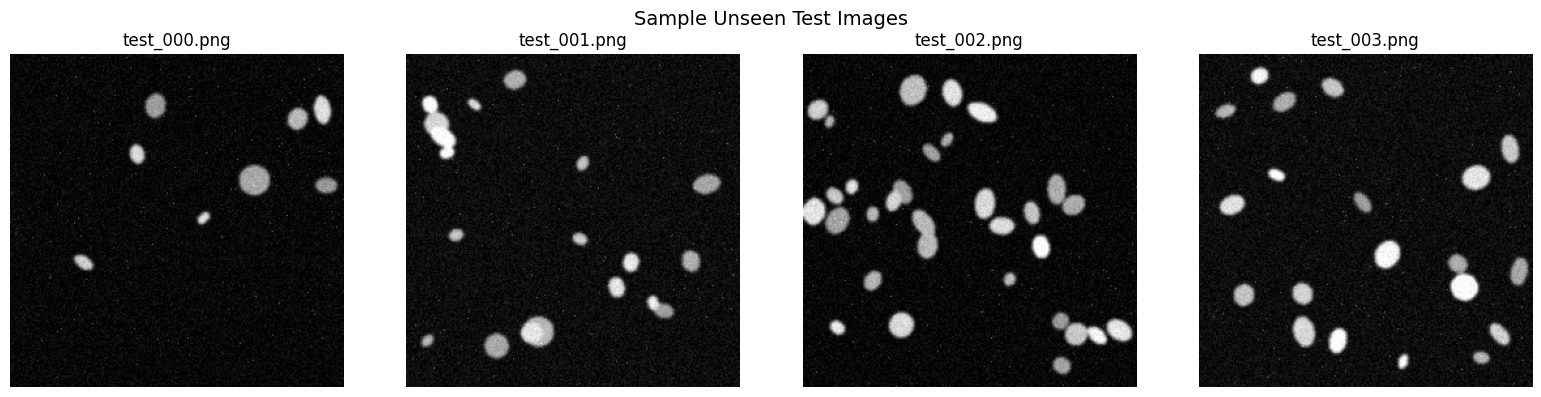

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\test_image_samples.png


In [10]:
# ============================================================
# CELL 8 — VISUAL SANITY CHECK
# ============================================================

sample_ids = sorted(test_images.keys())[:4]

fig, axes = plt.subplots(
    1,
    len(sample_ids),
    figsize=(16, 4)
)

for ax, image_id in zip(axes, sample_ids):

    ax.imshow(
        test_images[image_id],
        cmap="gray"
    )

    ax.set_title(image_id)
    ax.axis("off")

plt.suptitle(
    "Sample Unseen Test Images",
    fontsize=14
)

plt.tight_layout()

sample_image_path = os.path.join(
    HYBRID_OUTPUT_DIR,
    "test_image_samples.png"
)

plt.savefig(
    sample_image_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", sample_image_path)

In [17]:
# ============================================================
# CELL 9 — LOAD EXISTING U-NET TEST PREDICTIONS
# ============================================================

PREDICTION_DIR = os.path.join(
    OUTPUT_DIR,
    "test_predictions"
)

print("=" * 70)
print("CHECKING EXISTING U-NET TEST PREDICTIONS")
print("=" * 70)

print("Prediction directory:")
print(PREDICTION_DIR)

print("\nDirectory exists:",
      os.path.exists(PREDICTION_DIR))


# ------------------------------------------------------------
# Find predicted masks
# ------------------------------------------------------------

if not os.path.exists(PREDICTION_DIR):

    raise FileNotFoundError(
        "The existing U-Net prediction directory was not found."
    )


prediction_files = sorted([
    f for f in os.listdir(PREDICTION_DIR)
    if f.lower().endswith(
        (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    )
])


print(
    "\nNumber of predicted masks:",
    len(prediction_files)
)

print("\nPrediction files:")

for f in prediction_files:
    print(" ", f)


# ------------------------------------------------------------
# Verify expected test images
# ------------------------------------------------------------

expected_test_images = set(
    test_image_files
)

available_predictions = set(
    prediction_files
)

missing_predictions = sorted(
    expected_test_images - available_predictions
)

extra_predictions = sorted(
    available_predictions - expected_test_images
)


print("\nMissing predictions:",
      len(missing_predictions))

if missing_predictions:
    for f in missing_predictions:
        print(" ", f)


print("\nExtra prediction files:",
      len(extra_predictions))

if extra_predictions:
    for f in extra_predictions:
        print(" ", f)


# ------------------------------------------------------------
# Load predicted masks
# ------------------------------------------------------------

unet_masks = {}

for filename in prediction_files:

    path = os.path.join(
        PREDICTION_DIR,
        filename
    )

    mask = Image.open(
        path
    ).convert("L")

    mask_array = np.asarray(
        mask,
        dtype=np.float32
    ) / 255.0

    # Convert to binary
    binary_mask = (
        mask_array >= 0.5
    ).astype(np.uint8)

    unet_masks[filename] = binary_mask


# ------------------------------------------------------------
# Verify one mask
# ------------------------------------------------------------

if len(unet_masks) > 0:

    first_prediction = sorted(
        unet_masks.keys()
    )[0]

    first_mask = unet_masks[
        first_prediction
    ]

    print("\n" + "=" * 70)
    print("FIRST PREDICTION CHECK")
    print("=" * 70)

    print("Image:", first_prediction)
    print("Shape:", first_mask.shape)
    print("Unique values:",
          np.unique(first_mask))

    print(
        "Foreground pixels:",
        int(first_mask.sum())
    )

    print(
        "Foreground fraction:",
        f"{first_mask.mean():.4%}"
    )


print("\nExisting U-Net predictions loaded successfully.")

CHECKING EXISTING U-NET TEST PREDICTIONS
Prediction directory:
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\test_predictions

Directory exists: True

Number of predicted masks: 12

Prediction files:
  test_000.png
  test_001.png
  test_002.png
  test_003.png
  test_004.png
  test_005.png
  test_006.png
  test_007.png
  test_008.png
  test_009.png
  test_010.png
  test_011.png

Missing predictions: 0

Extra prediction files: 0

FIRST PREDICTION CHECK
Image: test_000.png
Shape: (256, 256)
Unique values: [0 1]
Foreground pixels: 1529
Foreground fraction: 2.3331%

Existing U-Net predictions loaded successfully.


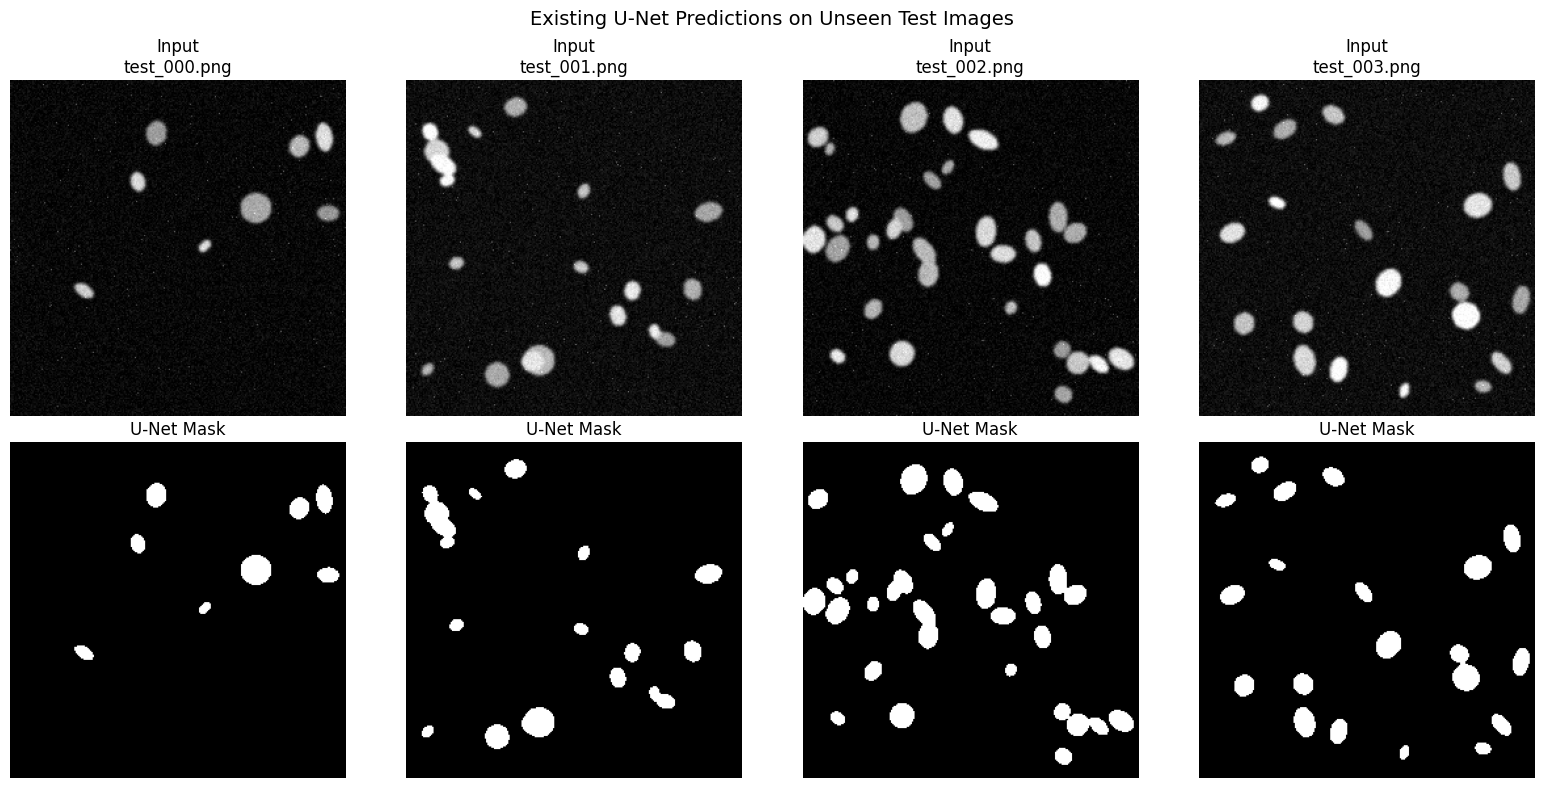

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\existing_unet_test_predictions.png


In [18]:
# ============================================================
# CELL 10 — VISUAL CHECK OF EXISTING U-NET MASKS
# ============================================================

sample_ids = sorted(
    unet_masks.keys()
)[:4]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

for col, image_id in enumerate(sample_ids):

    # Original grayscale image
    original = test_images[image_id]

    axes[0, col].imshow(
        original,
        cmap="gray"
    )

    axes[0, col].set_title(
        f"Input\n{image_id}"
    )

    axes[0, col].axis("off")


    # U-Net prediction
    axes[1, col].imshow(
        unet_masks[image_id],
        cmap="gray"
    )

    axes[1, col].set_title(
        "U-Net Mask"
    )

    axes[1, col].axis("off")


plt.suptitle(
    "Existing U-Net Predictions on Unseen Test Images",
    fontsize=14
)

plt.tight_layout()

preview_path = os.path.join(
    HYBRID_OUTPUT_DIR,
    "existing_unet_test_predictions.png"
)

plt.savefig(
    preview_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", preview_path)

## 3. Object-Level Feature Extraction

The predicted U-Net masks are converted into connected components and analysed using region-based measurements. Features such as object count, area, eccentricity, solidity, perimeter, intensity and foreground fraction provide an interpretable numerical summary of each segmented image.

These measurements are used as the only input to the numbers-first LLM stage.

In [19]:
# ============================================================
# CELL 11 — EXTRACT REGION FEATURES FROM U-NET MASKS
# ============================================================

from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_objects


def extract_region_features(
    image,
    binary_mask,
    min_object_area=20
):
    """
    Extract connected-component features from a U-Net mask.

    The mask is cleaned by removing very small components.
    Connected objects are then labelled and measured using
    regionprops_table.

    Returns:
        cleaned_mask : cleaned binary segmentation
        features_df  : per-object feature table
    """

    # --------------------------------------------------------
    # Ensure binary mask
    # --------------------------------------------------------

    mask = (
        binary_mask > 0
    ).astype(bool)

    # --------------------------------------------------------
    # Remove tiny isolated components
    # --------------------------------------------------------

    cleaned_mask = remove_small_objects(
        mask,
        min_size=min_object_area
    )

    # --------------------------------------------------------
    # Label connected components
    # --------------------------------------------------------

    labelled_mask = label(
        cleaned_mask,
        connectivity=2
    )

    # --------------------------------------------------------
    # Extract object-level measurements
    # --------------------------------------------------------

    properties = [
        "label",
        "area",
        "eccentricity",
        "solidity",
        "extent",
        "perimeter",
        "mean_intensity",
    ]

    features = regionprops_table(
        labelled_mask,
        intensity_image=image,
        properties=properties
    )

    features_df = pd.DataFrame(
        features
    )

    return cleaned_mask.astype(np.uint8), features_df


print("=" * 70)
print("REGION FEATURE EXTRACTION FUNCTION READY")
print("=" * 70)

REGION FEATURE EXTRACTION FUNCTION READY


In [20]:
# ============================================================
# CELL 12 — EXTRACT FEATURES FOR ALL TEST IMAGES
# ============================================================

all_feature_tables = {}
all_cleaned_masks = {}

print("=" * 70)
print("PROCESSING ALL TEST IMAGES")
print("=" * 70)

for image_id in sorted(unet_masks.keys()):

    # Original grayscale image
    image = test_images[image_id]

    # U-Net prediction
    mask = unet_masks[image_id]

    # Extract objects and features
    cleaned_mask, features_df = extract_region_features(
        image=image,
        binary_mask=mask,
        min_object_area=20
    )

    all_cleaned_masks[image_id] = cleaned_mask
    all_feature_tables[image_id] = features_df

    print(
        f"{image_id}: "
        f"{len(features_df)} objects"
    )


print("\nFeature extraction completed.")

PROCESSING ALL TEST IMAGES
test_000.png: 8 objects
test_001.png: 14 objects
test_002.png: 25 objects
test_003.png: 19 objects
test_004.png: 43 objects
test_005.png: 16 objects
test_006.png: 8 objects
test_007.png: 23 objects
test_008.png: 23 objects
test_009.png: 21 objects
test_010.png: 37 objects
test_011.png: 20 objects

Feature extraction completed.


In [21]:
# ============================================================
# CELL 13 — CREATE NUMERICAL SUMMARY FOR EACH TEST IMAGE
# ============================================================

def create_numerical_summary(
    image_id,
    image,
    features_df,
    cleaned_mask
):
    """
    Convert the per-object regionprops table into a compact
    numerical summary.

    The LLM will receive these numbers only.
    It will NOT receive the image.
    """

    n_objects = len(features_df)

    foreground_fraction = float(
        cleaned_mask.mean()
    )

    if n_objects == 0:

        return {
            "image_id": image_id,
            "n_objects": 0,
            "mean_area": 0.0,
            "median_area": 0.0,
            "mean_eccentricity": 0.0,
            "mean_solidity": 0.0,
            "mean_extent": 0.0,
            "mean_perimeter": 0.0,
            "mean_intensity": 0.0,
            "foreground_fraction": foreground_fraction
        }

    return {
        "image_id": image_id,

        "n_objects": int(n_objects),

        "mean_area": float(
            features_df["area"].mean()
        ),

        "median_area": float(
            features_df["area"].median()
        ),

        "mean_eccentricity": float(
            features_df["eccentricity"].mean()
        ),

        "mean_solidity": float(
            features_df["solidity"].mean()
        ),

        "mean_extent": float(
            features_df["extent"].mean()
        ),

        "mean_perimeter": float(
            features_df["perimeter"].mean()
        ),

        "mean_intensity": float(
            features_df["mean_intensity"].mean()
        ),

        "foreground_fraction": foreground_fraction
    }


numerical_summaries = {}

for image_id in sorted(
    all_feature_tables.keys()
):

    numerical_summaries[image_id] = (
        create_numerical_summary(
            image_id=image_id,
            image=test_images[image_id],
            features_df=all_feature_tables[image_id],
            cleaned_mask=all_cleaned_masks[image_id]
        )
    )


print("=" * 70)
print("NUMERICAL SUMMARIES CREATED")
print("=" * 70)

for image_id, summary in numerical_summaries.items():

    print(
        f"{image_id}: "
        f"{summary['n_objects']} objects, "
        f"mean area = {summary['mean_area']:.2f}"
    )

NUMERICAL SUMMARIES CREATED
test_000.png: 8 objects, mean area = 191.12
test_001.png: 14 objects, mean area = 200.36
test_002.png: 25 objects, mean area = 226.84
test_003.png: 19 objects, mean area = 203.47
test_004.png: 43 objects, mean area = 329.49
test_005.png: 16 objects, mean area = 407.88
test_006.png: 8 objects, mean area = 197.38
test_007.png: 23 objects, mean area = 206.30
test_008.png: 23 objects, mean area = 240.61
test_009.png: 21 objects, mean area = 178.62
test_010.png: 37 objects, mean area = 353.35
test_011.png: 20 objects, mean area = 183.60


In [22]:
# ============================================================
# CELL 14 — AGGREGATED TEST FEATURE DATAFRAME
# ============================================================

feature_summary_df = pd.DataFrame(
    list(
        numerical_summaries.values()
    )
)

feature_summary_df = (
    feature_summary_df
    .sort_values("image_id")
    .reset_index(drop=True)
)


print("=" * 70)
print("AGGREGATED NUMERICAL FEATURE TABLE")
print("=" * 70)

display(
    feature_summary_df
)


# ------------------------------------------------------------
# Save numerical feature table
# ------------------------------------------------------------

feature_csv_path = os.path.join(
    HYBRID_OUTPUT_DIR,
    "test_region_feature_summaries.csv"
)

feature_summary_df.to_csv(
    feature_csv_path,
    index=False
)

print(
    "\nSaved:",
    feature_csv_path
)

AGGREGATED NUMERICAL FEATURE TABLE


,image_id,n_objects,mean_area,median_area,mean_eccentricity,mean_solidity,mean_extent,mean_perimeter,mean_intensity,foreground_fraction
0,test_000.png,8,191.125000,177.0,0.636627,0.966006,0.759878,48.011300,0.232403,0.023331
1,test_001.png,14,200.357143,163.5,0.634555,0.945187,0.734620,51.027273,0.239064,0.042801
2,test_002.png,25,226.840000,201.0,0.671896,0.945638,0.743616,55.904372,0.246643,0.086533
3,test_003.png,19,203.473684,199.0,0.698072,0.958894,0.755668,51.461134,0.260508,0.058990
4,test_004.png,43,329.488372,235.0,0.658601,0.929950,0.716689,69.938505,0.257349,0.216187
5,test_005.png,16,407.875000,227.0,0.638062,0.930294,0.739213,76.010288,0.251862,0.099579
6,test_006.png,8,197.375000,203.5,0.621186,0.960526,0.754875,48.968407,0.278091,0.024094
7,test_007.png,23,206.304348,149.0,0.649965,0.940931,0.735967,51.388177,0.252222,0.072403
8,test_008.png,23,240.608696,175.0,0.598113,0.946098,0.761146,55.917906,0.249910,0.084442
9,test_009.png,21,178.619048,139.0,0.617801,0.956891,0.765436,46.878468,0.244432,0.057236



Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\test_region_feature_summaries.csv


In [23]:
# ============================================================
# CELL 15 — SAVE PER-OBJECT REGIONPROPS TABLES
# ============================================================

REGION_TABLE_DIR = os.path.join(
    HYBRID_OUTPUT_DIR,
    "region_tables"
)

os.makedirs(
    REGION_TABLE_DIR,
    exist_ok=True
)


for image_id, features_df in all_feature_tables.items():

    output_name = (
        image_id.replace(".png", "")
                .replace(".jpg", "")
                .replace(".jpeg", "")
        + "_regionprops.csv"
    )

    output_path = os.path.join(
        REGION_TABLE_DIR,
        output_name
    )

    features_df.to_csv(
        output_path,
        index=False
    )


print("=" * 70)
print("REGIONPROPS TABLES SAVED")
print("=" * 70)

print(
    "Directory:",
    REGION_TABLE_DIR
)

print(
    "Tables saved:",
    len(all_feature_tables)
)

REGIONPROPS TABLES SAVED
Directory: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\region_tables
Tables saved: 12


In [24]:
# ============================================================
# CELL 16 — NUMBERS-ONLY LLM PROMPT
# ============================================================

NUMBERS_FIRST_SYSTEM_PROMPT = """
You are a cautious scientific image-analysis assistant.

You are interpreting numerical measurements extracted from a
segmented image.

IMPORTANT RULES:

1. You are NOT seeing the original image.
2. Do not invent visual details.
3. Do not identify a medical diagnosis.
4. Base every statement only on the numerical measurements.
5. If the numbers do not support a conclusion, say "uncertain".
6. Treat the structured JSON record as the source of truth.
7. Return valid JSON for the structured record.

Required JSON fields:

{
  "n_objects": integer,
  "density_class": "low" | "moderate" | "high" | "uncertain",
  "shape_regularity": "regular" | "mixed" | "irregular" | "uncertain",
  "quality_flag": "good" | "acceptable" | "poor" | "uncertain"
}
"""


def build_numbers_first_prompt(summary):
    """
    Convert numerical measurements into a numbers-only
    LLM request.
    """

    return f"""
Analyse the following numerical measurements only.

IMAGE ID:
{summary["image_id"]}

NUMBER OF OBJECTS:
{summary["n_objects"]}

MEAN AREA:
{summary["mean_area"]:.4f}

MEDIAN AREA:
{summary["median_area"]:.4f}

MEAN ECCENTRICITY:
{summary["mean_eccentricity"]:.4f}

MEAN SOLIDITY:
{summary["mean_solidity"]:.4f}

MEAN EXTENT:
{summary["mean_extent"]:.4f}

MEAN PERIMETER:
{summary["mean_perimeter"]:.4f}

MEAN INTENSITY:
{summary["mean_intensity"]:.4f}

FOREGROUND FRACTION:
{summary["foreground_fraction"]:.6f}

First provide one cautious paragraph describing what these
measurements indicate.

Then provide a JSON object with exactly these fields:

{{
  "n_objects": integer,
  "density_class": "low" | "moderate" | "high" | "uncertain",
  "shape_regularity": "regular" | "mixed" | "irregular" | "uncertain",
  "quality_flag": "good" | "acceptable" | "poor" | "uncertain"
}}

Do not describe anything that cannot be supported by the numbers.
"""

In [26]:
# ============================================================
# CELL 17 — NUMBERS-FIRST LLM TEST
# ============================================================

import requests
import json


OLLAMA_URL = "http://localhost:11434/api/chat"

LLM_MODEL = "qwen2.5vl:latest"


# ------------------------------------------------------------
# Use the numerical summary already created
# ------------------------------------------------------------

test_summary = numerical_summaries[
    "test_000.png"
]

numbers_prompt = build_numbers_first_prompt(
    test_summary
)


# ------------------------------------------------------------
# Keep the request deliberately short
# ------------------------------------------------------------

short_numbers_prompt = f"""
Use ONLY the numerical measurements below.

Do not discuss an image you cannot see.
Do not diagnose anything.
Do not invent visual features.

Give:
1. One short paragraph based only on the numbers.
2. A JSON object with exactly these fields:

{{
  "n_objects": integer,
  "density_class": "low" | "moderate" | "high" | "uncertain",
  "shape_regularity": "regular" | "mixed" | "irregular" | "uncertain",
  "quality_flag": "good" | "acceptable" | "poor" | "uncertain"
}}

Measurements:

image_id: {test_summary["image_id"]}
n_objects: {test_summary["n_objects"]}
mean_area: {test_summary["mean_area"]:.4f}
median_area: {test_summary["median_area"]:.4f}
mean_eccentricity: {test_summary["mean_eccentricity"]:.4f}
mean_solidity: {test_summary["mean_solidity"]:.4f}
mean_extent: {test_summary["mean_extent"]:.4f}
mean_perimeter: {test_summary["mean_perimeter"]:.4f}
mean_intensity: {test_summary["mean_intensity"]:.4f}
foreground_fraction: {test_summary["foreground_fraction"]:.6f}

Keep the paragraph under 60 words.
"""


# ------------------------------------------------------------
# Ollama request
# ------------------------------------------------------------

payload = {
    "model": LLM_MODEL,

    "messages": [
        {
            "role": "system",
            "content": (
                "You are a cautious scientific assistant. "
                "Use only the supplied numerical measurements. "
                "If something cannot be determined, say uncertain."
            )
        },
        {
            "role": "user",
            "content": short_numbers_prompt
        }
    ],

    "stream": False,

    "options": {
        "temperature": 0.1,
        "num_predict": 200
    }
}


print("=" * 70)
print("NUMBERS-FIRST LLM TEST")
print("=" * 70)

print("Model:", LLM_MODEL)
print("Sending numerical data only...")
print("Maximum generated tokens: 200")
print("Timeout: 5 minutes")

try:

    response = requests.post(
        OLLAMA_URL,
        json=payload,
        timeout=300
    )

    print(
        "\nHTTP status:",
        response.status_code
    )

    response.raise_for_status()

    result = response.json()

    numbers_first_raw = (
        result["message"]["content"]
    )

    print("\nLLM OUTPUT")
    print("-" * 70)
    print(numbers_first_raw)

except requests.exceptions.ReadTimeout:

    print("\nERROR: Ollama did not finish within 5 minutes.")
    print(
        "The Ollama server is reachable, but generation is too slow."
    )

except requests.exceptions.ConnectionError:

    print(
        "\nERROR: Could not connect to Ollama."
    )

except requests.exceptions.HTTPError as e:

    print(
        "\nHTTP ERROR:",
        e
    )

NUMBERS-FIRST LLM TEST
Model: qwen2.5vl:latest
Sending numerical data only...
Maximum generated tokens: 200
Timeout: 5 minutes

HTTP status: 200

LLM OUTPUT
----------------------------------------------------------------------
The image contains 8 objects with a moderate density, irregular shapes, and an acceptable quality. The mean eccentricity and solidity suggest varied elongation and compactness, respectively. The low foreground fraction indicates minimal object presence in the image.

{
  "n_objects": 8,
  "density_class": "moderate",
  "shape_regularity": "irregular",
  "quality_flag": "acceptable"
}


In [27]:
# ============================================================
# CELL 18 — PARSE NUMBERS-FIRST JSON
# ============================================================

def extract_json_object(text):
    """
    Extract the first JSON object from an LLM response.
    """

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:

        return None

    candidate = text[
        start:end + 1
    ]

    try:

        return json.loads(
            candidate
        )

    except json.JSONDecodeError:

        return None


numbers_first_json = extract_json_object(
    numbers_first_raw
)


print("=" * 70)
print("PARSED NUMBERS-FIRST JSON")
print("=" * 70)

if numbers_first_json is None:

    print(
        "No valid JSON object was detected."
    )

else:

    print(
        json.dumps(
            numbers_first_json,
            indent=2
        )
    )

PARSED NUMBERS-FIRST JSON
{
  "n_objects": 8,
  "density_class": "moderate",
  "shape_regularity": "irregular",
  "quality_flag": "acceptable"
}


In [28]:
# ============================================================
# CELL 19 — SAVE NUMBERS-FIRST EXAMPLE
# ============================================================

numbers_first_example = {
    "image_id": "test_000.png",
    "numerical_summary": test_summary,
    "llm_json": numbers_first_json,
    "llm_raw_response": numbers_first_raw
}


numbers_first_json_path = os.path.join(
    HYBRID_OUTPUT_DIR,
    "test_000_numbers_first_output.json"
)


with open(
    numbers_first_json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        numbers_first_example,
        f,
        indent=2
    )


print("=" * 70)
print("NUMBERS-FIRST OUTPUT SAVED")
print("=" * 70)

print(
    numbers_first_json_path
)

NUMBERS-FIRST OUTPUT SAVED
C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\test_000_numbers_first_output.json


## 4. Numbers-First LLM Interpretation

The numerical summaries are passed to the local Qwen model without providing the original images. The prompt restricts the model to the supplied measurements and requests both a short narrative and structured JSON fields.

The structured output contains `n_objects`, `density_class`, `shape_regularity` and `quality_flag`. Using numerical inputs rather than images makes the LLM stage easier to audit because its evidence can be inspected independently.

In [29]:
# ============================================================
# CELL 20 — NUMBERS-FIRST LLM FUNCTION
# ============================================================

def run_numbers_first_llm(summary):
    """
    Send numerical measurements only to the local LLM.

    The LLM does not receive the original image.
    """

    prompt = f"""
Use ONLY the numerical measurements below.

Do not describe visual details that are not supported
by the numbers. Do not diagnose anything.

Return:
1. One short paragraph based only on the measurements.
2. A JSON object with exactly these fields:

{{
  "n_objects": integer,
  "density_class": "low" | "moderate" | "high" | "uncertain",
  "shape_regularity": "regular" | "mixed" | "irregular" | "uncertain",
  "quality_flag": "good" | "acceptable" | "poor" | "uncertain"
}}

Keep the paragraph under 80 words.

Measurements:

image_id: {summary["image_id"]}
n_objects: {summary["n_objects"]}
mean_area: {summary["mean_area"]:.4f}
median_area: {summary["median_area"]:.4f}
mean_eccentricity: {summary["mean_eccentricity"]:.4f}
mean_solidity: {summary["mean_solidity"]:.4f}
mean_extent: {summary["mean_extent"]:.4f}
mean_perimeter: {summary["mean_perimeter"]:.4f}
mean_intensity: {summary["mean_intensity"]:.4f}
foreground_fraction: {summary["foreground_fraction"]:.6f}
"""

    payload = {
        "model": LLM_MODEL,

        "messages": [
            {
                "role": "system",
                "content": (
                    "You are a cautious scientific assistant. "
                    "Use only numerical evidence supplied by the user. "
                    "If a conclusion is unsupported, return uncertain."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        "stream": False,

        "options": {
            "temperature": 0.1,
            "num_predict": 220
        }
    }

    response = requests.post(
        OLLAMA_URL,
        json=payload,
        timeout=300
    )

    response.raise_for_status()

    result = response.json()

    raw_output = result[
        "message"
    ][
        "content"
    ]

    parsed_json = extract_json_object(
        raw_output
    )

    return raw_output, parsed_json


print("=" * 70)
print("NUMBERS-FIRST LLM FUNCTION READY")
print("=" * 70)

NUMBERS-FIRST LLM FUNCTION READY


In [30]:
# ============================================================
# CELL 21 — RUN LLM ON ALL TEST IMAGES
# ============================================================

llm_results = {}

image_ids = sorted(
    numerical_summaries.keys()
)

print("=" * 70)
print("RUNNING NUMBERS-FIRST LLM ON ALL TEST IMAGES")
print("=" * 70)

print(
    "Images to process:",
    len(image_ids)
)

for i, image_id in enumerate(
    image_ids,
    start=1
):

    print(
        f"\n[{i}/{len(image_ids)}] {image_id}"
    )

    summary = numerical_summaries[
        image_id
    ]

    try:

        raw_output, parsed_json = (
            run_numbers_first_llm(
                summary
            )
        )

        llm_results[image_id] = {
            "raw_output": raw_output,
            "json": parsed_json,
            "status": "success"
        }

        print(
            "Status: SUCCESS"
        )

        if parsed_json is not None:

            print(
                "JSON parsed successfully."
            )

        else:

            print(
                "WARNING: JSON could not be parsed."
            )

    except Exception as e:

        llm_results[image_id] = {
            "raw_output": "",
            "json": None,
            "status": "failed",
            "error": str(e)
        }

        print(
            "Status: FAILED"
        )

        print(
            "Error:",
            str(e)
        )


successful = sum(
    1
    for r in llm_results.values()
    if r["status"] == "success"
)

failed = len(llm_results) - successful


print("\n" + "=" * 70)
print("LLM PROCESSING COMPLETE")
print("=" * 70)

print("Successful:", successful)
print("Failed    :", failed)

RUNNING NUMBERS-FIRST LLM ON ALL TEST IMAGES
Images to process: 12

[1/12] test_000.png
Status: SUCCESS
JSON parsed successfully.

[2/12] test_001.png
Status: SUCCESS
JSON parsed successfully.

[3/12] test_002.png
Status: SUCCESS
JSON parsed successfully.

[4/12] test_003.png
Status: SUCCESS
JSON parsed successfully.

[5/12] test_004.png
Status: SUCCESS
JSON parsed successfully.

[6/12] test_005.png
Status: SUCCESS
JSON parsed successfully.

[7/12] test_006.png
Status: SUCCESS
JSON parsed successfully.

[8/12] test_007.png
Status: SUCCESS
JSON parsed successfully.

[9/12] test_008.png
Status: SUCCESS
JSON parsed successfully.

[10/12] test_009.png
Status: SUCCESS
JSON parsed successfully.

[11/12] test_010.png
Status: SUCCESS
JSON parsed successfully.

[12/12] test_011.png
Status: SUCCESS
JSON parsed successfully.

LLM PROCESSING COMPLETE
Successful: 12
Failed    : 0


In [31]:
# ============================================================
# CELL 22 — INSPECT STRUCTURED JSON RECORDS
# ============================================================

print("=" * 70)
print("STRUCTURED JSON RECORDS")
print("=" * 70)

for image_id in image_ids:

    result = llm_results[
        image_id
    ]

    print("\n" + "-" * 70)

    print(
        "IMAGE:",
        image_id
    )

    print(
        "STATUS:",
        result["status"]
    )

    if result["json"] is not None:

        print(
            json.dumps(
                result["json"],
                indent=2
            )
        )

    else:

        print(
            "No valid JSON record."
        )

STRUCTURED JSON RECORDS

----------------------------------------------------------------------
IMAGE: test_000.png
STATUS: success
{
  "n_objects": 8,
  "density_class": "moderate",
  "shape_regularity": "irregular",
  "quality_flag": "acceptable"
}

----------------------------------------------------------------------
IMAGE: test_001.png
STATUS: success
{
  "n_objects": 14,
  "density_class": "moderate",
  "shape_regularity": "regular",
  "quality_flag": "acceptable"
}

----------------------------------------------------------------------
IMAGE: test_002.png
STATUS: success
{
  "n_objects": 25,
  "density_class": "moderate",
  "shape_regularity": "regular",
  "quality_flag": "acceptable"
}

----------------------------------------------------------------------
IMAGE: test_003.png
STATUS: success
{
  "n_objects": 19,
  "density_class": "moderate",
  "shape_regularity": "regular",
  "quality_flag": "acceptable"
}

----------------------------------------------------------------------

## 5. Aggregate and Save the Hybrid Results

The numerical measurements and structured LLM outputs are combined into one pandas DataFrame with one row per unseen test image.

The results are saved both as an aggregated CSV and as individual JSON records. The raw LLM response is also retained to support auditability and comparison with the structured representation.

In [32]:
# ============================================================
# CELL 23 — BUILD FINAL HYBRID JSON DATAFRAME
# ============================================================

final_records = []

for image_id in image_ids:

    summary = numerical_summaries[
        image_id
    ]

    llm_result = llm_results[
        image_id
    ]

    structured = (
        llm_result["json"]
    )

    if structured is None:

        structured = {
            "n_objects": summary["n_objects"],
            "density_class": "uncertain",
            "shape_regularity": "uncertain",
            "quality_flag": "uncertain"
        }

    record = {

        "image_id": image_id,

        "n_objects": int(
            structured.get(
                "n_objects",
                summary["n_objects"]
            )
        ),

        "mean_area": float(
            summary["mean_area"]
        ),

        "density_class": structured.get(
            "density_class",
            "uncertain"
        ),

        "quality_flag": structured.get(
            "quality_flag",
            "uncertain"
        ),

        # Keep this for auditability
        "shape_regularity": structured.get(
            "shape_regularity",
            "uncertain"
        ),

        "mean_eccentricity": float(
            summary["mean_eccentricity"]
        ),

        "mean_solidity": float(
            summary["mean_solidity"]
        ),

        "foreground_fraction": float(
            summary["foreground_fraction"]
        ),

        "llm_status": llm_result[
            "status"
        ]
    }

    final_records.append(
        record
    )


hybrid_results_df = pd.DataFrame(
    final_records
)


hybrid_results_df = (
    hybrid_results_df
    .sort_values("image_id")
    .reset_index(drop=True)
)


print("=" * 70)
print("FINAL HYBRID PIPELINE DATAFRAME")
print("=" * 70)

display(
    hybrid_results_df
)

FINAL HYBRID PIPELINE DATAFRAME


,image_id,n_objects,mean_area,density_class,quality_flag,shape_regularity,mean_eccentricity,mean_solidity,foreground_fraction,llm_status
0,test_000.png,8,191.125000,moderate,acceptable,irregular,0.636627,0.966006,0.023331,success
1,test_001.png,14,200.357143,moderate,acceptable,regular,0.634555,0.945187,0.042801,success
2,test_002.png,25,226.840000,moderate,acceptable,regular,0.671896,0.945638,0.086533,success
3,test_003.png,19,203.473684,moderate,acceptable,regular,0.698072,0.958894,0.058990,success
4,test_004.png,43,329.488372,moderate,acceptable,regular,0.658601,0.929950,0.216187,success
5,test_005.png,16,407.875000,moderate,acceptable,regular,0.638062,0.930294,0.099579,success
6,test_006.png,8,197.375000,moderate,acceptable,regular,0.621186,0.960526,0.024094,success
7,test_007.png,23,206.304348,moderate,acceptable,regular,0.649965,0.940931,0.072403,success
8,test_008.png,23,240.608696,moderate,acceptable,regular,0.598113,0.946098,0.084442,success
9,test_009.png,21,178.619048,moderate,acceptable,irregular,0.617801,0.956891,0.057236,success


In [33]:
# ============================================================
# CELL 24 — SAVE FINAL REQUIRED CSV
# ============================================================

FINAL_CSV_PATH = os.path.join(
    HYBRID_OUTPUT_DIR,
    "hybrid_test_results.csv"
)

hybrid_results_df.to_csv(
    FINAL_CSV_PATH,
    index=False
)


print("=" * 70)
print("FINAL HYBRID CSV SAVED")
print("=" * 70)

print(
    "Path:",
    FINAL_CSV_PATH
)

print(
    "Rows:",
    len(hybrid_results_df)
)

print(
    "Columns:",
    len(hybrid_results_df.columns)
)

FINAL HYBRID CSV SAVED
Path: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\hybrid_test_results.csv
Rows: 12
Columns: 10


In [34]:
# ============================================================
# CELL 25 — SAVE ALL JSON RECORDS
# ============================================================

JSON_OUTPUT_DIR = os.path.join(
    HYBRID_OUTPUT_DIR,
    "json_records"
)

os.makedirs(
    JSON_OUTPUT_DIR,
    exist_ok=True
)


for image_id in image_ids:

    summary = numerical_summaries[
        image_id
    ]

    llm_result = llm_results[
        image_id
    ]

    record = {

        "image_id": image_id,

        "numerical_summary": summary,

        "structured_json": (
            llm_result["json"]
        ),

        "raw_llm_response": (
            llm_result["raw_output"]
        ),

        "status": (
            llm_result["status"]
        )
    }

    filename = (
        image_id
        .replace(".png", "")
        .replace(".jpg", "")
        .replace(".jpeg", "")
        + "_hybrid_record.json"
    )

    path = os.path.join(
        JSON_OUTPUT_DIR,
        filename
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            record,
            f,
            indent=2
        )


print("=" * 70)
print("JSON RECORDS SAVED")
print("=" * 70)

print(
    "Directory:",
    JSON_OUTPUT_DIR
)

print(
    "Records:",
    len(image_ids)
)

JSON RECORDS SAVED
Directory: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\json_records
Records: 12


## 6. Narratives, Visualisation and Final Reporting Outputs

The human-readable narratives are added to the structured results, followed by summary statistics, example JSON output and a visual example of the segmentation stage.

These outputs provide the evidence needed to document Task 4 in the final report while keeping the structured JSON as the main machine-readable result.

In [35]:
# ============================================================
# CELL 26 — EXTRACT NARRATIVE FROM LLM OUTPUT
# ============================================================

def extract_narrative(
    raw_output,
    parsed_json
):
    """
    Extract the narrative portion of the LLM response.

    The JSON portion is removed so that the resulting text
    contains only the descriptive paragraph.
    """

    if not raw_output:

        return "No narrative generated."

    text = raw_output.strip()

    # Find the beginning of the JSON object
    json_start = text.find("{")

    if json_start != -1:

        narrative = text[
            :json_start
        ].strip()

    else:

        narrative = text

    # Remove common labels
    for prefix in [
        "Narrative:",
        "Description:",
        "Description -",
        "Analysis:"
    ]:

        if narrative.lower().startswith(
            prefix.lower()
        ):

            narrative = narrative[
                len(prefix):
            ].strip()

    return narrative


narratives = {}

for image_id in image_ids:

    result = llm_results[
        image_id
    ]

    narratives[image_id] = (
        extract_narrative(
            result["raw_output"],
            result["json"]
        )
    )


print("=" * 70)
print("NARRATIVES EXTRACTED")
print("=" * 70)

for image_id in image_ids:

    print("\n" + "-" * 70)

    print(image_id)

    print(
        narratives[image_id]
    )

NARRATIVES EXTRACTED

----------------------------------------------------------------------
test_000.png
The image contains 8 objects with a moderate density, irregular shapes, and an acceptable quality. The objects are relatively small and have a high solidity, suggesting compact shapes. The foreground fraction is very low, indicating that the objects are not prominent in the image.

----------------------------------------------------------------------
test_001.png
The image contains 14 objects with a moderate density, regular shape, and an acceptable quality. The objects have a mean eccentricity of 0.6346, suggesting some elongation, and a mean solidity of 0.9452, indicating a relatively compact shape. The foreground fraction of 0.042801 suggests a small proportion of the image is occupied by the objects.

----------------------------------------------------------------------
test_002.png
The image contains 25 objects with a moderate density, regular shape, and an acceptable qualit

In [36]:
# ============================================================
# CELL 27 — ADD NARRATIVES TO FINAL RESULTS
# ============================================================

hybrid_results_df[
    "narrative"
] = hybrid_results_df[
    "image_id"
].map(
    narratives
)


display(
    hybrid_results_df[
        [
            "image_id",
            "n_objects",
            "mean_area",
            "density_class",
            "quality_flag",
            "narrative"
        ]
    ]
)

,image_id,n_objects,mean_area,density_class,quality_flag,narrative
0,test_000.png,8,191.125000,moderate,acceptable,The image contains 8 objects with a moderate d...
1,test_001.png,14,200.357143,moderate,acceptable,The image contains 14 objects with a moderate ...
2,test_002.png,25,226.840000,moderate,acceptable,The image contains 25 objects with a moderate ...
3,test_003.png,19,203.473684,moderate,acceptable,The image contains 19 objects with a moderate ...
4,test_004.png,43,329.488372,moderate,acceptable,The image contains 43 objects with a moderate ...
5,test_005.png,16,407.875000,moderate,acceptable,The image contains 16 objects with a moderate ...
6,test_006.png,8,197.375000,moderate,acceptable,The image contains 8 objects with a moderate d...
7,test_007.png,23,206.304348,moderate,acceptable,The image contains 23 objects with a moderate ...
8,test_008.png,23,240.608696,moderate,acceptable,The image contains 23 objects with a moderate ...
9,test_009.png,21,178.619048,moderate,acceptable,The image contains 21 objects with a moderate ...


In [37]:
# ============================================================
# CELL 28 — SAVE FINAL REPORT-READY CSV
# ============================================================

FINAL_REPORT_CSV = os.path.join(
    HYBRID_OUTPUT_DIR,
    "hybrid_pipeline_final_results.csv"
)

hybrid_results_df.to_csv(
    FINAL_REPORT_CSV,
    index=False
)


print("=" * 70)
print("FINAL REPORT-READY RESULTS")
print("=" * 70)

print(
    "Rows:",
    len(hybrid_results_df)
)

print(
    "CSV:",
    FINAL_REPORT_CSV
)

print("\nColumns:")

for column in hybrid_results_df.columns:

    print(
        " •",
        column
    )

FINAL REPORT-READY RESULTS
Rows: 12
CSV: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\hybrid_pipeline_final_results.csv

Columns:
 • image_id
 • n_objects
 • mean_area
 • density_class
 • quality_flag
 • shape_regularity
 • mean_eccentricity
 • mean_solidity
 • foreground_fraction
 • llm_status
 • narrative


In [38]:
# ============================================================
# CELL 29 — FINAL HYBRID RESULTS OVERVIEW
# ============================================================

print("=" * 70)
print("FINAL HYBRID PIPELINE OVERVIEW")
print("=" * 70)

print(f"Test images processed : {len(hybrid_results_df)}")
print(
    "Successful LLM records:",
    (hybrid_results_df["llm_status"] == "success").sum()
)
print(
    "Failed LLM records    :",
    (hybrid_results_df["llm_status"] != "success").sum()
)

print("\nRequired Task 4 fields:")
required_columns = [
    "image_id",
    "n_objects",
    "mean_area",
    "density_class",
    "quality_flag",
    "narrative"
]

for column in required_columns:
    print(
        f"  {'✓' if column in hybrid_results_df.columns else '✗'} "
        f"{column}"
    )

print("\nFinal results:")
display(
    hybrid_results_df[
        required_columns
    ]
)

FINAL HYBRID PIPELINE OVERVIEW
Test images processed : 12
Successful LLM records: 12
Failed LLM records    : 0

Required Task 4 fields:
  ✓ image_id
  ✓ n_objects
  ✓ mean_area
  ✓ density_class
  ✓ quality_flag
  ✓ narrative

Final results:


,image_id,n_objects,mean_area,density_class,quality_flag,narrative
0,test_000.png,8,191.125000,moderate,acceptable,The image contains 8 objects with a moderate d...
1,test_001.png,14,200.357143,moderate,acceptable,The image contains 14 objects with a moderate ...
2,test_002.png,25,226.840000,moderate,acceptable,The image contains 25 objects with a moderate ...
3,test_003.png,19,203.473684,moderate,acceptable,The image contains 19 objects with a moderate ...
4,test_004.png,43,329.488372,moderate,acceptable,The image contains 43 objects with a moderate ...
5,test_005.png,16,407.875000,moderate,acceptable,The image contains 16 objects with a moderate ...
6,test_006.png,8,197.375000,moderate,acceptable,The image contains 8 objects with a moderate d...
7,test_007.png,23,206.304348,moderate,acceptable,The image contains 23 objects with a moderate ...
8,test_008.png,23,240.608696,moderate,acceptable,The image contains 23 objects with a moderate ...
9,test_009.png,21,178.619048,moderate,acceptable,The image contains 21 objects with a moderate ...


In [39]:
# ============================================================
# CELL 31 — LLM STRUCTURED OUTPUT SUMMARY
# ============================================================

print("=" * 70)
print("LLM STRUCTURED OUTPUT SUMMARY")
print("=" * 70)

print("\nDensity classes:")
display(
    hybrid_results_df[
        "density_class"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "density_class"
    ).reset_index(
        name="count"
    )
)

print("\nQuality flags:")
display(
    hybrid_results_df[
        "quality_flag"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "quality_flag"
    ).reset_index(
        name="count"
    )
)

print("\nShape regularity:")
display(
    hybrid_results_df[
        "shape_regularity"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "shape_regularity"
    ).reset_index(
        name="count"
    )
)

LLM STRUCTURED OUTPUT SUMMARY

Density classes:


,density_class,count
0,moderate,12



Quality flags:


,quality_flag,count
0,acceptable,12



Shape regularity:


,shape_regularity,count
0,regular,9
1,irregular,3


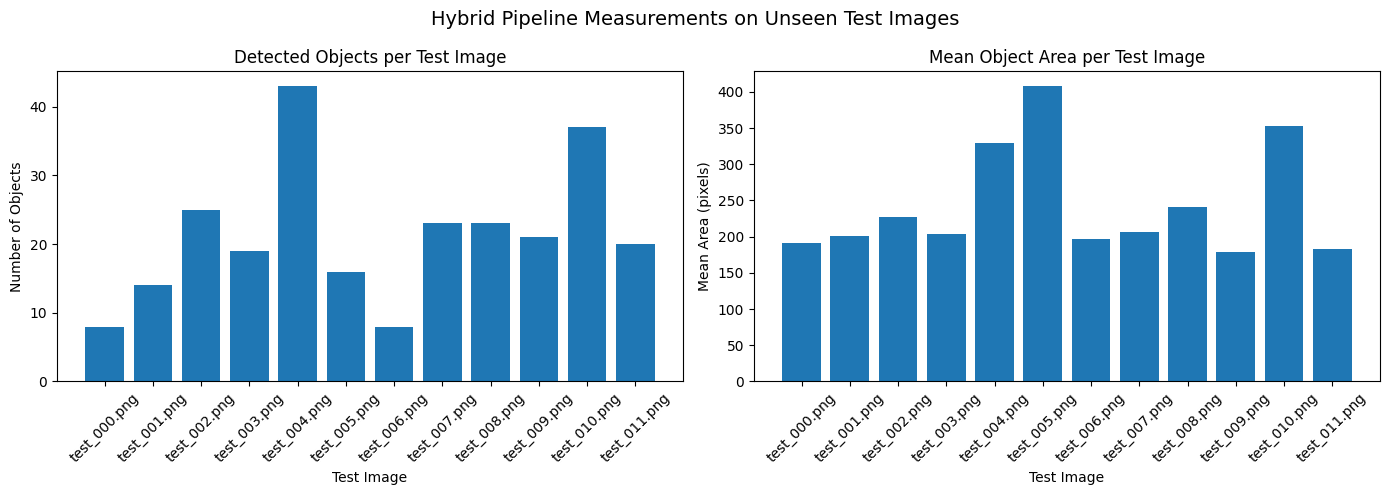

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\hybrid_pipeline_summary.png


In [40]:
# ============================================================
# CELL 32 — REPORT-READY HYBRID RESULTS FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# ------------------------------------------------------------
# Number of detected objects
# ------------------------------------------------------------

axes[0].bar(
    hybrid_results_df["image_id"],
    hybrid_results_df["n_objects"]
)

axes[0].set_title(
    "Detected Objects per Test Image"
)

axes[0].set_xlabel(
    "Test Image"
)

axes[0].set_ylabel(
    "Number of Objects"
)

axes[0].tick_params(
    axis="x",
    rotation=45
)


# ------------------------------------------------------------
# Mean object area
# ------------------------------------------------------------

axes[1].bar(
    hybrid_results_df["image_id"],
    hybrid_results_df["mean_area"]
)

axes[1].set_title(
    "Mean Object Area per Test Image"
)

axes[1].set_xlabel(
    "Test Image"
)

axes[1].set_ylabel(
    "Mean Area (pixels)"
)

axes[1].tick_params(
    axis="x",
    rotation=45
)


plt.suptitle(
    "Hybrid Pipeline Measurements on Unseen Test Images",
    fontsize=14
)

plt.tight_layout()


hybrid_summary_figure = os.path.join(
    HYBRID_OUTPUT_DIR,
    "hybrid_pipeline_summary.png"
)

plt.savefig(
    hybrid_summary_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    hybrid_summary_figure
)

In [41]:
# ============================================================
# CELL 33 — REPORT-READY EXAMPLE JSON AND NARRATIVE
# ============================================================

example_image_id = (
    sorted(
        hybrid_results_df["image_id"]
        .tolist()
    )[0]
)

example_row = hybrid_results_df[
    hybrid_results_df["image_id"]
    == example_image_id
].iloc[0]


example_json = {
    "image_id": example_row["image_id"],
    "n_objects": int(
        example_row["n_objects"]
    ),
    "mean_area": float(
        example_row["mean_area"]
    ),
    "density_class": example_row[
        "density_class"
    ],
    "quality_flag": example_row[
        "quality_flag"
    ]
}


print("=" * 70)
print("REPORT-READY EXAMPLE")
print("=" * 70)

print("\nIMAGE ID:")
print(
    example_image_id
)

print("\nSTRUCTURED JSON:")
print(
    json.dumps(
        example_json,
        indent=2
    )
)

print("\nNARRATIVE:")
print(
    example_row["narrative"]
)

REPORT-READY EXAMPLE

IMAGE ID:
test_000.png

STRUCTURED JSON:
{
  "image_id": "test_000.png",
  "n_objects": 8,
  "mean_area": 191.125,
  "density_class": "moderate",
  "quality_flag": "acceptable"
}

NARRATIVE:
The image contains 8 objects with a moderate density, irregular shapes, and an acceptable quality. The objects are relatively small and have a high solidity, suggesting compact shapes. The foreground fraction is very low, indicating that the objects are not prominent in the image.


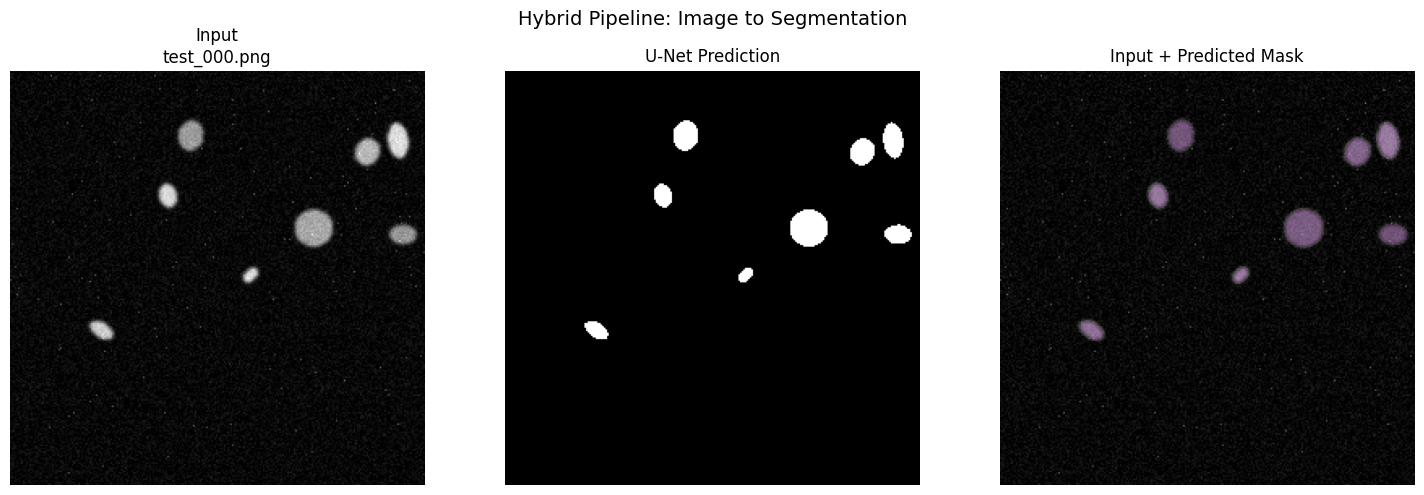

Saved: C:\Users\gms\OneDrive - University of Hertfordshire\Data Analysis with AI\Assingnment 3\outputs\hybrid_pipeline\hybrid_pipeline_visual_example.png


In [42]:
# ============================================================
# CELL 34 — REPORT-READY HYBRID PIPELINE VISUAL
# ============================================================

example_image_id = (
    sorted(
        test_images.keys()
    )[0]
)

original = test_images[
    example_image_id
]

mask = unet_masks[
    example_image_id
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

axes[0].imshow(
    original,
    cmap="gray"
)

axes[0].set_title(
    f"Input\n{example_image_id}"
)

axes[0].axis("off")


# ------------------------------------------------------------
# U-Net prediction
# ------------------------------------------------------------

axes[1].imshow(
    mask,
    cmap="gray"
)

axes[1].set_title(
    "U-Net Prediction"
)

axes[1].axis("off")


# ------------------------------------------------------------
# Overlay
# ------------------------------------------------------------

axes[2].imshow(
    original,
    cmap="gray"
)

axes[2].imshow(
    np.ma.masked_where(
        mask == 0,
        mask
    ),
    alpha=0.45
)

axes[2].set_title(
    "Input + Predicted Mask"
)

axes[2].axis("off")


plt.suptitle(
    "Hybrid Pipeline: Image to Segmentation",
    fontsize=14
)

plt.tight_layout()


hybrid_visual_path = os.path.join(
    HYBRID_OUTPUT_DIR,
    "hybrid_pipeline_visual_example.png"
)

plt.savefig(
    hybrid_visual_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    hybrid_visual_path
)

## 7. Final Task 4 Verification

The final checks confirm that all 12 unseen test images passed through the complete hybrid pipeline and that the required masks, numerical summaries, LLM records, JSON files, CSV results and report-ready figures were successfully generated.

In [43]:
# ============================================================
# CELL 35 — FINAL TASK 4 VERIFICATION
# ============================================================

print("=" * 70)
print("TASK 4 — FINAL VERIFICATION")
print("=" * 70)

checks = {
    "12 unseen test images processed":
        len(test_images) == 12,

    "12 U-Net masks available":
        len(unet_masks) == 12,

    "12 numerical summaries available":
        len(numerical_summaries) == 12,

    "12 LLM results available":
        len(llm_results) == 12,

    "All LLM requests successful":
        all(
            r["status"] == "success"
            for r in llm_results.values()
        ),

    "Final DataFrame contains 12 rows":
        len(hybrid_results_df) == 12,

    "Final CSV exists":
        os.path.exists(
            FINAL_REPORT_CSV
        ),

    "JSON output directory exists":
        os.path.exists(
            JSON_OUTPUT_DIR
        ),

    "Hybrid summary figure exists":
        os.path.exists(
            hybrid_summary_figure
        ),

    "Hybrid visual example exists":
        os.path.exists(
            hybrid_visual_path
        )
}


all_passed = True

for description, passed in checks.items():

    symbol = "✓" if passed else "✗"

    print(
        f"{symbol} {description}"
    )

    if not passed:
        all_passed = False


print("\n" + "=" * 70)

if all_passed:

    print(
        "TASK 4 COMPLETE — ALL CHECKS PASSED"
    )

else:

    print(
        "TASK 4 INCOMPLETE — CHECK THE FAILED ITEMS"
    )

print("=" * 70)

TASK 4 — FINAL VERIFICATION
✓ 12 unseen test images processed
✓ 12 U-Net masks available
✓ 12 numerical summaries available
✓ 12 LLM results available
✓ All LLM requests successful
✓ Final DataFrame contains 12 rows
✓ Final CSV exists
✓ JSON output directory exists
✓ Hybrid summary figure exists
✓ Hybrid visual example exists

TASK 4 COMPLETE — ALL CHECKS PASSED
